# 1. Wprowadzenie
- **Autor:** Karolina Stefańska s227822
- **Temat projektu:** Analiza i identyfikacja kluczowych czynników wpływających na wartość
nieruchomości w celu predykcji przyszłej wartości (ceny za noc) obiektu w regionie Azji i Pacyfiku
dostępnego do wynajmu na platformie Airbnb.
- **Cel projektu:** Głównym celem projektu jest stworzenie modelu uczenia maszynowego (regresji),
który pozwoli na przewidywanie przychodu z wynajmu Airbnb w regionie Azji i Pacyfiku. Projekt ma
na celu pomoc w podejmowaniu decyzji inwestycyjnych dla przyszłych hostów (właścicieli
apartamentów na platformie Airbnb). <br>
Projekt zakłada wykorzystanie zmiennych subiektywnych (oceny, liczba opinii) jako dodatkowych
parametrów, pozwalających na długoterminową analizę. Dzięki temu użytkownik (inwestor) będzie
mógł oszacować zarówno bazową cenę nowej oferty, jak i potencjalny wzrost przychodów po
uzyskaniu statusu Superhosta lub wysokich ocen. Dzięki temu model mógłby być również przydatny
dla obecnych właścicieli, by zweryfikować i zoptymalizować cenę za noc ich nieruchomości.

# 2. Zbiór danych
- **Źródło:** https://www.kaggle.com/datasets/jasonairroi/airbnb-market-data-asia-pacific
- **Liczba obserwacji:** 29,440
- **Liczba zmiennych:** 61, w tym finalnie 12, które zostaną wzięte pod uwagę w modelu. Ostatnie 2 zmienne z tabeli to tworzą zmienną objaśnianą
- **Cecha do przewidzenia przez model:** przychód w USD

In [1147]:
import pandas as pd
import numpy as np
zmienne= pd.DataFrame([
    ('guests','maksymakna liczba gości', 'skokowa'),
    ('bedrooms', 'liczba sypialni', 'skokowa'),
    ('beds' ,'liczba łóżek', 'skokowa'),
    ('room_type','standard prywatności','kategoryczna (3)'),
    ('listing_type', 'standard akomodacji', 'kategoryczna') ,
    ('latitude', 'szerokość geograficza', 'ciągła'),
    ('longitude', 'długość geograficzna' ,'ciągła'),
    ('city', 'miasto', 'kategoryczna'),
    ('superhost', 'status superhosta', 'binarna'),
    ('num_reviews', 'lb. opinii', 'skokowa'),
    ('rating_overall', 'średnie opinie', 'ciągła'),
    ('photos_count', 'liczba zdjęć', 'skokowa'),
    ('instant_book', 'możliwość natychmiastowej rezerwacji', 'binarna'),
    ('l90d_revenue', 'przychód w USD', 'ciągła'),
    ], columns=('nazwa zmiennej', 'opis zmiennej', 'typ zmiennej'))
zmienne


,nazwa zmiennej,opis zmiennej,typ zmiennej
0,guests,maksymakna liczba gości,skokowa
1,bedrooms,liczba sypialni,skokowa
2,beds,liczba łóżek,skokowa
3,room_type,standard prywatności,kategoryczna (3)
4,listing_type,standard akomodacji,kategoryczna
5,latitude,szerokość geograficza,ciągła
6,longitude,długość geograficzna,ciągła
7,city,miasto,kategoryczna
8,superhost,status superhosta,binarna
9,num_reviews,lb. opinii,skokowa


## Wczytywanie danych i opis danych
oczyszczam dane z " na początku i końcu linii i zamieniam podwójne cudzysłowy z kolumny o udogodnieniach. Nastpęnie wczytuję dane z pliku csv pomijając wersy z błędami (wersy te nie mają listing_id)

In [1148]:
with open('listings.csv', 'r', encoding='utf-8') as file:
    clean_lines=[line.strip('"').replace('""', '"') for line in file]

with open('listings_cleaned.csv', 'w', encoding='utf-8') as file_out:
    for line in clean_lines:
        file_out.write(line)

In [1149]:
pd.set_option('display.max_columns', None)
listings_all_data = pd.read_csv(
    'listings_cleaned.csv', 
    quotechar='"', 
    doublequote=True, 
    skipinitialspace=True,
    on_bad_lines='skip'
)
listings_all_data.head(8)
listings_all_data.columns


C:\Users\karol\AppData\Local\Temp\ipykernel_10380\3960223325.py:2: DtypeWarning: Columns (0: photos_count, 1: latitude, 2: guests, 3: bedrooms, 4: num_reviews, 5: l90d_available_days, 6: l90d_total_days) have mixed types. Specify dtype option on import or set low_memory=False.
  listings_all_data = pd.read_csv(


Index(['listing_id', 'listing_type', 'room_type', 'cover_photo_url',
       'photos_count', 'host_id', 'superhost', 'latitude', 'longitude',
       'guests', 'bedrooms', 'beds', 'baths', 'registration', 'amenities',
       'instant_book', 'professional_management', 'min_nights',
       'cancellation_policy', 'currency', 'cleaning_fee', 'extra_guest_fee',
       'num_reviews', 'rating_overall', 'rating_accuracy', 'rating_checkin',
       'rating_cleanliness', 'rating_communication', 'rating_location',
       'rating_value', 'ttm_revenue', 'ttm_revenue_native', 'ttm_avg_rate',
       'ttm_avg_rate_native', 'ttm_occupancy', 'ttm_adjusted_occupancy',
       'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar',
       'ttm_adjusted_revpar_native', 'ttm_reserved_days', 'ttm_blocked_days',
       'ttm_available_days', 'ttm_total_days', 'l90d_revenue',
       'l90d_revenue_native', 'l90d_avg_rate', 'l90d_avg_rate_native',
       'l90d_occupancy', 'l90d_adjusted_occupancy', 'l90d_revpar',
 

tworzę ramkę danych tylko z kolumn, które mnie interesują

In [1150]:
nazwy_zmiennych=list(zmienne.loc[:,'nazwa zmiennej'])
listings_df=listings_all_data.loc[:,nazwy_zmiennych]
listings_df.head(5)

,guests,bedrooms,beds,room_type,listing_type,latitude,longitude,city,superhost,num_reviews,rating_overall,photos_count,instant_book,l90d_revenue
0,14,7,10.0,entire_home,Entire villa,-8.6867,115.1564,"Seminyak""",false,73.0,4.52,43.0,NaN,11007.0
1,6,3,3.0,entire_home,Entire villa,-8.6958,115.1725,"Seminyak""",true,152.0,4.72,21.0,NaN,5759.0
2,10,4,4.0,entire_home,Entire villa,-8.6927,115.1657,"Seminyak""",true,118.0,4.71,18.0,NaN,5110.0
3,8,4,5.0,entire_home,Entire villa,-8.6905,115.1640,"Seminyak""",true,127.0,4.91,80.0,NaN,22294.0
4,14,7,8.0,entire_home,Entire villa,-8.6908,115.1632,"Seminyak""",true,6.0,4.80,63.0,NaN,16164.0


In [1151]:
listings_df['city'] = listings_df['city'].map(lambda x: str(x).strip('"'))
listings_df.head(3)

,guests,bedrooms,beds,room_type,listing_type,latitude,longitude,city,superhost,num_reviews,rating_overall,photos_count,instant_book,l90d_revenue
0,14,7,10.0,entire_home,Entire villa,-8.6867,115.1564,Seminyak,false,73.0,4.52,43.0,NaN,11007.0
1,6,3,3.0,entire_home,Entire villa,-8.6958,115.1725,Seminyak,true,152.0,4.72,21.0,NaN,5759.0
2,10,4,4.0,entire_home,Entire villa,-8.6927,115.1657,Seminyak,true,118.0,4.71,18.0,NaN,5110.0


In [1152]:
listings_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29169 entries, 0 to 29168
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   guests          24614 non-null  object 
 1   bedrooms        22476 non-null  object 
 2   beds            28292 non-null  float64
 3   room_type       28787 non-null  str    
 4   listing_type    28787 non-null  str    
 5   latitude        28786 non-null  object 
 6   longitude       28786 non-null  float64
 7   city            29169 non-null  str    
 8   superhost       28785 non-null  str    
 9   num_reviews     28748 non-null  object 
 10  rating_overall  27832 non-null  float64
 11  photos_count    28497 non-null  object 
 12  instant_book    3412 non-null   str    
 13  l90d_revenue    28779 non-null  float64
dtypes: float64(4), object(5), str(5)
memory usage: 3.1+ MB


In [1153]:
listings_df['guests'] = pd.to_numeric(listings_df['guests'], errors='coerce')
listings_df['bedrooms'] = pd.to_numeric(listings_df['bedrooms'], errors='coerce')
listings_df['latitude'] = pd.to_numeric(listings_df['latitude'], errors='coerce')
listings_df['num_reviews'] = pd.to_numeric(listings_df['num_reviews'], errors='coerce')
listings_df['photos_count'] = pd.to_numeric(listings_df['photos_count'], errors='coerce')
listings_df['superhost'] = listings_df['superhost'].map(lambda x: False if x=='False' else True)

In [1154]:
listings_df.describe()

,guests,bedrooms,beds,latitude,longitude,num_reviews,rating_overall,photos_count,l90d_revenue
count,24613.000000,22475.000000,28292.000000,28785.000000,28786.000000,28747.000000,27832.000000,2.849600e+04,2.877900e+04
mean,4.796774,2.060156,2.646861,5.603658,119.627171,121.817380,4.761141,7.439223e+04,3.282858e+03
std,3.272582,1.544837,2.356941,22.970648,23.574772,325.902086,0.317681,4.458833e+06,1.523480e+04
min,1.000000,0.000000,0.000000,-45.076700,-121.981700,0.000000,2.500000,0.000000e+00,0.000000e+00
25%,2.000000,1.000000,1.000000,-8.513800,102.262200,28.000000,4.670000,1.700000e+01,1.500000e+02
50%,4.000000,2.000000,2.000000,10.364100,120.300900,74.000000,4.810000,2.700000e+01,9.520000e+02
75%,6.000000,3.000000,3.000000,19.070200,128.946625,165.000000,4.900000,4.100000e+01,3.208000e+03
max,16.000000,41.000000,42.000000,129.274500,176.309400,50358.000000,45.700000,3.740323e+08,2.316489e+06


## Analiza brakujących wartości
Sprawdzam procentową zawartość braków danych w każdej kolumnie. Najwięcej ich jest w instant_book, więc w następnym kroku pozbędę się tej kolumny. Dużo braków danych jest również w guests oraz bedrooms. 

In [1155]:
listings_df.isnull().sum()/len(listings_df)

guests            0.156193
bedrooms          0.229490
beds              0.030066
room_type         0.013096
listing_type      0.013096
latitude          0.013165
longitude         0.013130
city              0.000000
superhost         0.000000
num_reviews       0.014467
rating_overall    0.045836
photos_count      0.023072
instant_book      0.883027
l90d_revenue      0.013370
dtype: float64

In [1156]:
listings_df=listings_df.drop('instant_book', axis=1)

In [1157]:
listings_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29169 entries, 0 to 29168
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   guests          24613 non-null  float64
 1   bedrooms        22475 non-null  float64
 2   beds            28292 non-null  float64
 3   room_type       28787 non-null  str    
 4   listing_type    28787 non-null  str    
 5   latitude        28785 non-null  float64
 6   longitude       28786 non-null  float64
 7   city            29169 non-null  str    
 8   superhost       29169 non-null  bool   
 9   num_reviews     28747 non-null  float64
 10  rating_overall  27832 non-null  float64
 11  photos_count    28496 non-null  float64
 12  l90d_revenue    28779 non-null  float64
dtypes: bool(1), float64(9), str(3)
memory usage: 2.7 MB


Zajmuję się usunięciem wartości nan z pierwszych trzech kolumn

In [1158]:
listings_df[['guests', 'bedrooms', 'beds']].info()

<class 'pandas.DataFrame'>
RangeIndex: 29169 entries, 0 to 29168
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   guests    24613 non-null  float64
 1   bedrooms  22475 non-null  float64
 2   beds      28292 non-null  float64
dtypes: float64(3)
memory usage: 683.8 KB


Obliczam ile łóżek przypada średnio na każdą sypialnię by uzupełnić te wartości i zaokrąglę wynik do pełnej liczby

In [1159]:
dzielenie=listings_df['bedrooms']/listings_df['beds']
mask0=(dzielenie>0) & (dzielenie.notnull()) & (dzielenie!=np.inf)
dzielenie_rooms_beds=dzielenie[mask0].mean()
print(dzielenie_rooms_beds)

0.8161491197254633


In [1160]:
dzielenie=listings_df['guests']/listings_df['bedrooms']
dzielenie_guests_rooms=dzielenie[mask0].mean()
print(dzielenie_guests_rooms)

2.5965980683025522


In [1161]:
mask1 = listings_df['bedrooms'].isnull()
listings_df.loc[mask1, 'bedrooms'] = listings_df.loc[mask1, 'beds'] *dzielenie_rooms_beds

mask1 = listings_df['bedrooms'].isnull() #aktualizacja maski
listings_df.loc[mask1, 'bedrooms'] = listings_df.loc[mask1, 'guests'] / dzielenie_guests_rooms

mask2 = listings_df['guests'].isnull()
listings_df.loc[mask2, 'guests'] = listings_df.loc[mask2, 'bedrooms'] * dzielenie_guests_rooms

mask3 = listings_df['beds'].isnull()
listings_df.loc[mask3, 'beds'] = listings_df.loc[mask3, 'bedrooms'] / dzielenie_rooms_beds

In [1162]:
listings_df = listings_df.dropna(subset=['guests', 'bedrooms', 'beds'])

Po usunięciu braków danych z pierwszych trzech kolumn nie ma wiele więcej wierszy z wartościami pustymi, w kolumnach które mają pojedyncze braki danych, te rekordy po prostu opuszczam

In [1163]:
listings_df.info()

<class 'pandas.DataFrame'>
Index: 28768 entries, 0 to 29168
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   guests          28768 non-null  float64
 1   bedrooms        28768 non-null  float64
 2   beds            28768 non-null  float64
 3   room_type       28768 non-null  str    
 4   listing_type    28768 non-null  str    
 5   latitude        28767 non-null  float64
 6   longitude       28768 non-null  float64
 7   city            28768 non-null  str    
 8   superhost       28768 non-null  bool   
 9   num_reviews     28729 non-null  float64
 10  rating_overall  27814 non-null  float64
 11  photos_count    28477 non-null  float64
 12  l90d_revenue    28761 non-null  float64
dtypes: bool(1), float64(9), str(3)
memory usage: 2.9 MB


In [1164]:
listings_df = listings_df.dropna(subset=['latitude', 'superhost', 'l90d_revenue', 'city'])

columns_to_clean=['num_reviews', 'rating_overall', 'photos_count']
listings_df[columns_to_clean]=listings_df[columns_to_clean].fillna(listings_df[columns_to_clean].mean())

In [1165]:
listings_df.to_csv('listings_used.csv', index=False)

## Analiza wartości odstających

In [1166]:
listings_df.describe()

,guests,bedrooms,beds,latitude,longitude,num_reviews,rating_overall,photos_count,l90d_revenue
count,28760.000000,28760.000000,28760.000000,28760.000000,28760.000000,28760.000000,28760.000000,2.876000e+04,2.876000e+04
mean,4.632161,1.886684,2.635292,5.557711,119.649248,119.978043,4.759615,4.286399e+04,3.283113e+03
std,3.337199,1.478726,2.369003,22.900002,23.502522,135.559608,0.198416,3.453414e+06,1.523974e+04
min,0.000000,0.000000,0.000000,-45.076700,-121.981700,0.000000,2.500000,0.000000e+00,0.000000e+00
25%,2.000000,1.000000,1.000000,-8.514475,102.262275,28.000000,4.680000,1.700000e+01,1.490000e+02
50%,4.000000,1.000000,2.000000,10.354700,120.300300,74.000000,4.800000,2.700000e+01,9.515000e+02
75%,6.000000,2.000000,3.000000,19.063125,128.939600,164.250000,4.890000,4.200000e+01,3.205000e+03
max,72.704746,41.000000,50.235918,129.274500,176.309400,1523.000000,5.000000,3.387967e+08,2.316489e+06


- Już na wstępie widać, że mamy oferty z zerowym przychodem oraz takie, które przez ostatnie 90 dni zarobiły ponad 2 mln, te wartości odstające należy usunąć. 
    - W pierwszym kroku usunę wszystkie wartości zerowe
    - Następnie zawężę analizowane dane, aby nie uwzględniały najbardziej odstających ofert
- Do tego nie możliwy jest photos_count na tak wysokim poziomie, jednak 75% ofert ma jedynie około 43 zdjęcia, dlatego należy zmienić wartości najbardziej odstające
    - W tym celu zrównam skrajnie duże wartości 

### Usunięcie lokazji ze skrajnymi przychodami

In [1167]:
listings_df=listings_df[listings_df['l90d_revenue']>0]

In [1168]:
Q1_revenue=listings_df['l90d_revenue'].quantile(0.25)
Q3_revenue=listings_df['l90d_revenue'].quantile(0.75)

IQR_revenue = Q3_revenue - Q1_revenue

lower_revenue=Q1_revenue-1.5*IQR_revenue
upper_revenue=Q3_revenue+1.5*IQR_revenue
df_cleaned = listings_df[(listings_df['l90d_revenue'] >= lower_revenue) & (listings_df['l90d_revenue'] <= upper_revenue)]
len(listings_df)-len(df_cleaned)

2393

usunie to wiele rekordów, należy przyjąć inną strategię, spróbuję usunąć jedynie rekordy poniżej percentyla 0.05 oraz powyżej 0.95

In [1169]:
lower_revenue=listings_df['l90d_revenue'].quantile(0.05)
upper_revenue=listings_df['l90d_revenue'].quantile(0.95)
df_cleaned=listings_df[(listings_df['l90d_revenue'] >= lower_revenue) & (listings_df['l90d_revenue'] <= upper_revenue)]
len(listings_df)-len(df_cleaned)
print(len(df_cleaned))

20923


In [1170]:
listings_df=df_cleaned
del df_cleaned

### Wyrównanie liczby zdjęć

Sprawdzam, jaka jest największa sensowna wartość photos_count, która nie zaburzy wnioskowania modelu: jest to percentyl 0.98

In [1171]:
max_photos=listings_df['photos_count'].quantile(0.98)
print(max_photos)

118.0


In [1172]:
mask=listings_df['photos_count']>max_photos
listings_df.loc[mask,'photos_count']=max_photos

In [1205]:
listings_df.describe()

,guests,bedrooms,beds,center_dist_km,num_reviews,rating_overall,photos_count,l90d_revenue
count,20273.000000,20273.000000,20273.000000,20273.000000,20273.000000,20273.000000,20273.000000,20273.000000
mean,4.287281,1.698531,2.325906,5.546831,133.102821,4.769172,33.048587,2776.776698
std,2.673886,0.981343,1.538433,9.791785,143.638405,0.186035,22.562304,3224.749824
min,0.000000,0.000000,0.000000,0.010138,1.000000,2.670000,1.000000,111.000000
25%,2.000000,1.000000,1.000000,1.212534,34.000000,4.690000,17.000000,584.000000
50%,4.000000,1.000000,2.000000,2.407909,86.000000,4.810000,27.000000,1459.000000
75%,6.000000,2.000000,3.000000,5.469714,183.000000,4.900000,42.000000,3628.000000
max,16.000000,5.713044,8.000000,78.711977,1523.000000,5.000000,118.000000,15647.000000


### Usunięcie lokalizacji z odsatjącą liczbą gości

In [ ]:
listings_df=listings_df[listings_df['guests'].quantile(0.99)]
listings_df=listings_df[listings_df['bedrooms']<listings_df['bedrooms'].quantile(0.99)]
listings_df=listings_df[listings_df['beds']<listings_df['beds'].quantile(0.99)]

## Edycja danych

Dla lepszej czytelności i poprawy działania modelu potrzebuję znormalizować niektóre kolumny:
- listings_type, których jest zbyt dużo choć część w praktyce oznacza to samo
- latitude i longitude oraz city, te trzy kolumny nie dadzą modelowi jasnej wskazówki jak działać, obliczę więc odległość od centrum miasta, aby dały lepszy obraz 

### Normalizacja etykiet listings_type
Po wyświetleniu statystyk widać że typów jest aż 105, z czego część oznacza to samo, a część jest typem odstającycm, stworzę słownik aby pogrupować te nazwy

In [1175]:
print((listings_df['listing_type'].value_counts(normalize=True) * 100).tail(10))

listing_type
entire_home                 0.004779
cafe street                 0.004779
Shared room in townhouse    0.004779
Shared room in dome         0.004779
Shared room in apartment    0.004779
Entire resort               0.004779
Boat                        0.004779
Shared room                 0.004779
Private room in floor       0.004779
Tower                       0.004779
Name: proportion, dtype: float64


In [1176]:
print((listings_df['listing_type'].value_counts(normalize=True) * 100).head(15))

listing_type
Entire rental unit                   21.746403
Entire condo                         18.759260
Entire home                          12.388281
Entire villa                          6.251494
Private room in home                  5.974287
Entire serviced apartment             4.105530
Private room in rental unit           3.723175
Entire guesthouse                     2.059934
Entire guest suite                    2.007360
Entire townhouse                      1.887875
Room in boutique hotel                1.653683
Private room in bed and breakfast     1.653683
Private room in condo                 1.429049
Room in hotel                         1.323902
Entire loft                           1.213975
Name: proportion, dtype: float64


Ponieważ niektóre kategorie są mylące nie mogę zwyczajnie kategoryzować poprzez szukanie słów kluczy, stworzę 6 kategorii i pogrupuję je ręcznie:
- villas
- houses
- apartments
- boutiques & hotels
- uniques 

Najpierw usunę z kolumny listings_type część która oznacza status prywatności, jest ona już zawarta w kolumnie room_type, więc tu sztucznie powiększa liczbę kategorii

In [1177]:
dictionary={'Private room in': '','Shared room in': '', 'Room in': '', 'Entire': '', 'Shared': '', 'entire_home':'house', 'Private': ''}
listings_df['listing_type']=listings_df['listing_type'].replace(dictionary, regex=True).map(lambda x: x.lower().strip())

In [1178]:
lk = np.array(listings_df['listing_type'].value_counts().index.tolist())

Z listy wszystkich tagów przypisuję teraz poszczególne kategorie do grup, następnie utworzę z nich słownik aby były to jedyne kategorie. Na końcu sprawdzam czy wszystko się zgadza.

In [1179]:
uniques=lk[np.r_[49:54, 39:45,32,35, 28]]
houses=lk[np.r_[45:49,30:32,21:24,25:28, 17:20,14,10,5,6,2]]
villas=lk[np.r_[3]]
apartments=lk[np.r_[36:39, 33, 29,24,13,7,0,1]]
hotels=lk[np.r_[34, 20, 15:17, 11,12,8,9,4]]

In [1180]:
dictionary2={}
for item in uniques: dictionary2[str(item)]='unique'
for item in houses: dictionary2[str(item)]='house'
for item in villas: dictionary2[str(item)]='villa'
for item in apartments: dictionary2[str(item)]='apartment'
for item in hotels: dictionary2[str(item)]='hotel'

In [1181]:
listings_df['listing_type']=listings_df['listing_type'].replace(dictionary2)

In [1182]:
listings_df['listing_type'].unique()

<StringArray>
['villa', 'house', 'hotel', 'apartment', 'unique']
Length: 5, dtype: str

Na koniec zbadam jeszcze room_type

In [1227]:
listings_df['room_type'].unique()


<StringArray>
['entire_home', 'private_room', 'hotel_room', 'shared_room']
Length: 4, dtype: str

In [1228]:
listings_df['room_type']=listings_df['room_type'].replace({'hotel_room':'private_room'})

### Odległości od miast
Dla modelu bardziej miarodajnymi danymi będzie odległość od centrów miast, niż same współrzędne geograficzne. Centra turystyczne oblicze uśredniając współrzędne wszystkich apartamentów regionu. 

In [1183]:
centers=listings_df[['longitude', 'latitude']].groupby(listings_df['city']).mean()

In [1184]:
listings_df['center_longitude'] = listings_df['city'].map(centers['longitude'])
listings_df['center_latitude'] = listings_df['city'].map(centers['latitude'])

In [1185]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0 # Promień Ziemi w kilometrach
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2]) # Konwersja na radiany
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Wzór Haversine'a
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

values= haversine_distance(
    listings_df['latitude'], listings_df['longitude'],
    listings_df['center_latitude'], listings_df['center_longitude']
)

listings_df.insert(loc=8,column='center_dist_km', value=values) 

In [1186]:
listings_df.head(10)

,guests,bedrooms,beds,room_type,listing_type,latitude,longitude,city,center_dist_km,superhost,num_reviews,rating_overall,photos_count,l90d_revenue,center_longitude,center_latitude
0,14.0,7.0,10.0,entire_home,villa,-8.6867,115.1564,Seminyak,0.941203,True,73.0,4.52,43.0,11007.0,115.164665,-8.688911
1,6.0,3.0,3.0,entire_home,villa,-8.6958,115.1725,Seminyak,1.152569,True,152.0,4.72,21.0,5759.0,115.164665,-8.688911
2,10.0,4.0,4.0,entire_home,villa,-8.6927,115.1657,Seminyak,0.436419,True,118.0,4.71,18.0,5110.0,115.164665,-8.688911
5,7.0,3.0,3.0,entire_home,villa,-8.6949,115.1699,Seminyak,0.880096,True,12.0,4.67,24.0,1734.0,115.164665,-8.688911
6,4.0,2.0,2.0,entire_home,villa,-8.6955,115.1685,Seminyak,0.845271,True,402.0,4.73,12.0,6933.0,115.164665,-8.688911
7,12.0,5.0,9.0,entire_home,house,-8.6896,115.1617,Seminyak,0.334849,True,153.0,4.94,60.0,5508.0,115.164665,-8.688911
8,2.0,1.0,1.0,entire_home,villa,-8.6944,115.1790,Seminyak,1.689717,True,493.0,4.66,55.0,7352.0,115.164665,-8.688911
9,6.0,3.0,3.0,entire_home,villa,-8.6889,115.1677,Seminyak,0.333554,True,118.0,4.72,37.0,846.0,115.164665,-8.688911
10,4.0,2.0,2.0,entire_home,villa,-8.6848,115.1632,Seminyak,0.484649,True,329.0,4.84,54.0,3125.0,115.164665,-8.688911
11,8.0,4.0,4.0,entire_home,villa,-8.6890,115.1649,Seminyak,0.027623,True,182.0,4.80,83.0,9053.0,115.164665,-8.688911


In [1187]:
listings_df=listings_df.drop(['longitude', 'latitude', 'center_latitude', 'center_longitude'], axis=1)

In [1188]:
listings_df['center_dist_km'].sort_values(ascending=False).head(10)

22226    9412.262242
10850     195.442558
22015      78.711977
16169      78.646815
22099      77.528475
21982      77.429266
22080      77.421777
22223      77.420916
22128      77.366166
22072      77.334738
Name: center_dist_km, dtype: float64

usunę najbardziej odstające rekordy - 9tys km lub 200km od centrum miasta to z pewnością błąd w danych

In [1189]:
listings_df=listings_df[listings_df['center_dist_km']<100]

## Statystyki

In [1190]:
listings_df.describe()

,guests,bedrooms,beds,center_dist_km,num_reviews,rating_overall,photos_count,l90d_revenue
count,20921.000000,20921.000000,20921.000000,20921.000000,20921.000000,20921.000000,20921.000000,20921.000000
mean,4.590334,1.834917,2.578298,5.550974,131.606925,4.768191,33.611491,2839.306678
std,3.259991,1.337842,2.196048,9.791835,142.523004,0.186948,23.051352,3272.962523
min,0.000000,0.000000,0.000000,0.000000,1.000000,2.500000,1.000000,111.000000
25%,2.000000,1.000000,1.000000,1.217479,33.000000,4.690000,17.000000,595.000000
50%,4.000000,1.000000,2.000000,2.419569,85.000000,4.810000,27.000000,1496.000000
75%,6.000000,2.000000,3.000000,5.479268,181.000000,4.900000,43.000000,3744.000000
max,72.704746,41.000000,50.235918,78.711977,1523.000000,5.000000,118.000000,15647.000000


In [1191]:
print(listings_df['room_type'].value_counts(normalize=True) * 100)

room_type
entire_home                                                      75.656039
private_room                                                     22.374647
hotel_room                                                        1.237991
shared_room                                                       0.726543
close to the air\",Pension,entire_home,a5aeb87476a8,207121254     0.004780
Name: proportion, dtype: float64


In [1192]:
print((listings_df['listing_type'].value_counts(normalize=True) * 100))

listing_type
apartment    50.169686
house        29.343722
hotel        13.125568
villa         7.074232
unique        0.286793
Name: proportion, dtype: float64


In [1193]:
print(listings_df['city'].value_counts(normalize=True) * 100)

city
Osaka           1.281010
Baguio          1.247550
Tagaytay        1.228431
George Town     1.175852
Christchurch    1.156732
                  ...   
Noosa Heads     0.525787
Vũng Tàu        0.525787
Byron Bay       0.497108
Gurugram        0.463649
nan             0.004780
Name: proportion, Length: 113, dtype: float64


Usuwam zabłąkaną wartość nan

In [1194]:
listings_df['city'] = listings_df['city'].replace(['nan', 'NaN'], np.nan)
listings_df=listings_df.dropna()

# 3. Wizualizacja danych

In [1208]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("inferno")
plt.rcParams['figure.figsize'] = [6, 4]

## Wizualizacja rozkładów

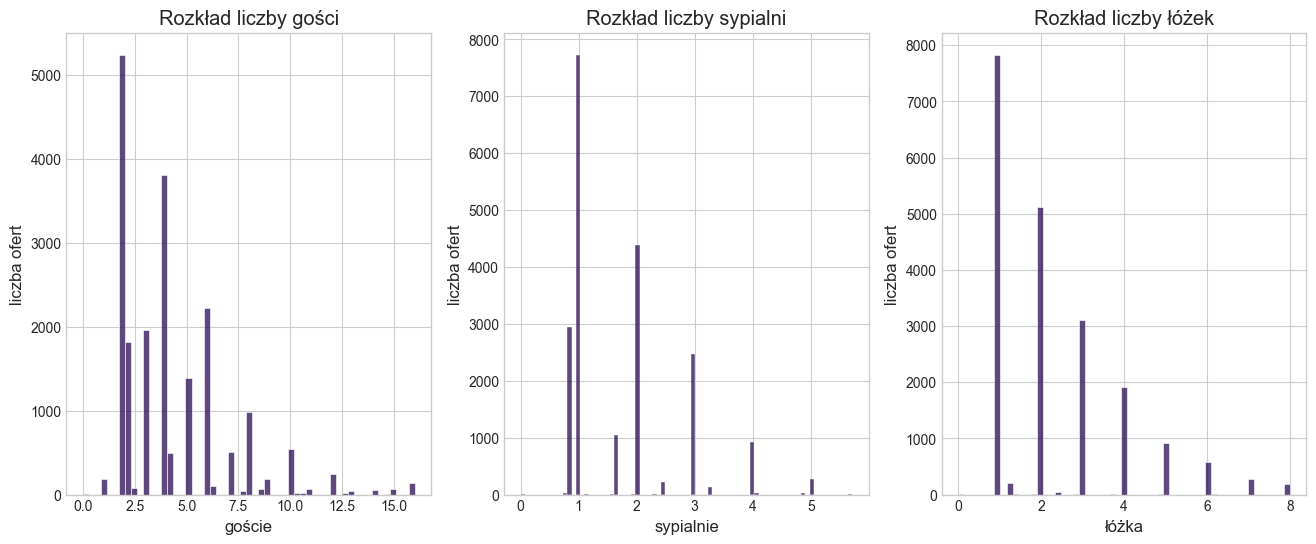

In [1214]:
fig, axes = plt.subplots(1,3, figsize=(16,6))

sns.histplot(data=listings_df, x='guests',ax=axes[0])
axes[0].set_title('Rozkład liczby gości')
axes[0].set_xlabel('goście')

sns.histplot(data=listings_df, x='bedrooms', ax=axes[1])
axes[1].set_title('Rozkład liczby sypialni')
axes[1].set_xlabel('sypialnie')

sns.histplot(data=listings_df, x='beds', ax=axes[2])
axes[2].set_title('Rozkład liczby łóżek')
axes[2].set_xlabel('łóżka')

for i in range(3):
    axes[i].set_ylabel('liczba ofert')

In [1216]:
listings_df[['guests', 'bedrooms', 'beds']].skew()

guests      1.639752
bedrooms    1.252474
beds        1.355389
dtype: float64

Liczba gości, sypialni i łóżek przypadająca na ofertę airbnb nie są danymi skokowymi, ich dyskretność została naruszona przez uzupełnienie średnią arytmetyczną. Nie mogę przez to narysować KDE - krzywej rozkładu. Widzę, że dane mają silną skośność prawostronną.

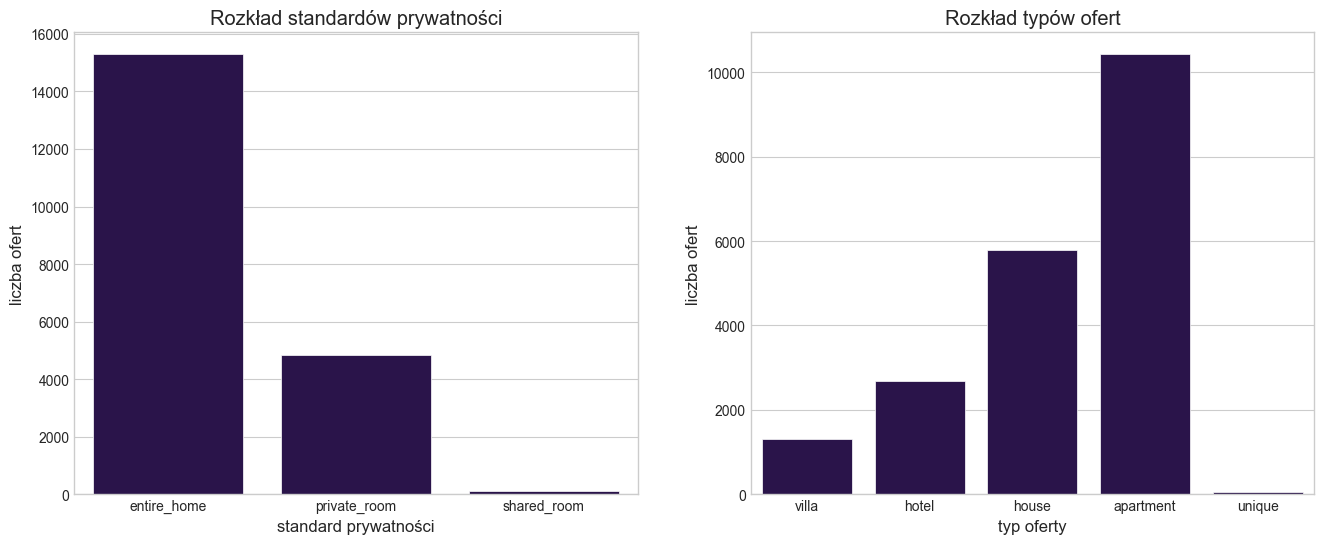

In [1232]:
fig, axes = plt.subplots(1,2, figsize=(16,6))

sns.countplot(data=listings_df, x='room_type',ax=axes[0])
axes[0].set_title('Rozkład standardów prywatności')
axes[0].set_xlabel('standard prywatności')

sns.countplot(data=listings_df, x='listing_type', ax=axes[1])
axes[1].set_title('Rozkład typów ofert')
axes[1].set_xlabel('typ oferty')

for i in range(2):
    axes[i].set_ylabel('liczba ofert')